# 01_回归算法-多项式核回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家聊聊回归算法中的多项式核回归\~

> 本文主要以 **SVR + 多项式核** 的形式讲解多项式核回归方法。

**一句话定义：**多项式核回归是一种可以让我们用「弯曲的线」而不是「直线」来拟合数据的回归方法，它是支持向量机（SVM）或核方法的一种应用方式。

可以把「回归」想成是我们试图画一条线，把一堆点（数据）大致连接起来，从而预测未知的点。

**普通的线性回归**：只能画直线。

比如我们要根据人的年龄预测身高，可能数据点差不多排成一条斜直线。

但现实中，数据可能是弯弯曲曲的：比如根据时间预测植物的高度，前期长得慢，后来飞快，然后又慢下来，这就不是直线能描述的。

这时候，**多项式核回归**就派上用场了。

它的核心思想是：

> 用一种「数学魔法」把原本不太好分、不太好拟合的数据，变成在某个高维空间中更容易用「直线」处理的数据。

这个「数学魔法」就是「核函数」，而「多项式核函数」就是其中一种，专门把数据“弯”一下，便于处理。

### 一个简单例子

假设我们有这样的数据：

| x（学习时间） | y（考试分数） |
|-|-|
| 1 | 50 |
| 2 | 55 |
| 3 | 60 |
| 4 | 75 |
| 5 | 95 |

如果你画图一看，发现分数不是匀速上升的，后面学得越多，提分越快，像个弯弯的上升曲线。

用直线画不准，用多项式（比如二次曲线）就能更好地贴合这些点。

这时候用**多项式核回归**，它能自动帮你“看出来”：我们用更适合的方式拟合，就能更准确地预测你学6小时会考多少分！

## 原理详解

### 数学原理

#### 1. 回归问题的基本目标

给定一组训练数据：


$$
\mathcal{D} = \{ (x_1, y_1), (x_2, y_2), \dots, (x_n, y_n) \}, \quad x_i \in \mathbb{R}^d, \quad y_i \in \mathbb{R}
$$


我们希望学到一个函数 $f(x)$，使得对任意输入 $x$，输出 $f(x) \approx y$。

#### 2. 线性回归模型

在线性回归中，我们假设模型是线性的：


$$
f(x) = w^T x + b
$$


我们通过最小化损失函数来求解最优参数：


$$
\min_{w, b} \sum_{i=1}^n (w^T x_i + b - y_i)^2
$$


#### 3. 非线性建模的思路：特征映射

现实中，很多问题是非线性的。我们可以使用一个**非线性变换** $\phi(x)$，将原始输入从输入空间 $\mathbb{R}^d$ 映射到更高维的特征空间：


$$
x \mapsto \phi(x), \quad \phi(x): \mathbb{R}^d \rightarrow \mathbb{R}^D \quad (D \gg d)
$$


然后在高维空间中做线性回归：


$$
f(x) = w^T \phi(x) + b
$$


## 核技巧与多项式核函数

### 1. 为什么要用核技巧

如果显式地计算 $\phi(x)$，当特征维度 $D$ 很高（或无限维）时，计算量会非常大。**核方法的关键**就是：**不显式计算** $\phi(x)$**，而是通过一个核函数** $K(x, x') = \phi(x)^T \phi(x')$ **直接计算内积**。

这样既避免了高维映射的开销，又保留了非线性表达能力。

### 2. 多项式核函数的定义

多项式核函数定义为：


$$
K(x, x') = (\langle x, x' \rangle + c)^d
$$


$\langle x, x' \rangle$：是输入空间的内积。

- $c$：是一个常数（一般 $c \ge 0$）。
- $d$：是多项式的阶数（比如 $d = 2$ 表示二次项）。

这个核函数对应一个高维映射 $\phi(x)$，它可以表示所有阶数小于等于 $d$ 的多项式组合。

## 核岭回归的公式推理（以 L2 正则化）

我们从一个常见的核回归模型推导开始，**核岭回归（Kernel Ridge Regression, KRR）**，即带有 L2 正则项的回归模型。

### 1. 原始优化问题

目标函数为最小化正则化平方损失：


$$
\min_{w} \frac{1}{2} \|w\|^2 + \frac{\lambda}{2} \sum_{i=1}^n (y_i - w^T \phi(x_i))^2
$$


其中：

- 第一项是正则化项（防止过拟合）
- 第二项是平方误差损失

$\lambda > 0$ 是正则化系数

### 2. 对偶形式推导（使用 Representer 定理）

根据 Representer Theorem，最优解 $w$ 一定存在于 $\phi(x_i)$ 的线性组合中：


$$
w = \sum_{i=1}^n \alpha_i \phi(x_i)
$$


因此预测函数可以写为：


$$
f(x) = w^T \phi(x) = \left( \sum_{i=1}^n \alpha_i \phi(x_i)^T \right) \phi(x) = \sum_{i=1}^n \alpha_i K(x_i, x)
$$


于是我们将问题转换为求解系数 $\alpha \in \mathbb{R}^n$

### 3. 求解公式推导

令 $K \in \mathbb{R}^{n \times n}$ 为核矩阵，其中：


$$
K_{ij} = K(x_i, x_j) = (\langle x_i, x_j \rangle + c)^d
$$


目标变成最小化：


$$
\frac{1}{2} \alpha^T K \alpha + \frac{\lambda}{2} \| y - K \alpha \|^2
$$


对上式对 $\alpha$ 求导，并令导数为 0：


$$
K \alpha + \lambda K (K \alpha - y) = 0\Rightarrow (K + \lambda I) \alpha = y
$$


最终解为：


$$
\boxed{\alpha = (K + \lambda I)^{-1} y}
$$


### 4. 最终的预测函数

对新的输入 $x$，预测值为：


$$
\boxed{f(x) = \sum_{i=1}^n \alpha_i K(x_i, x)}
$$


即不再需要直接计算高维 $\phi(x)$，只需要计算核函数。

## 算法流程

#### Step 1：准备数据

输入训练集 $\{(x_i, y_i)\}_{i=1}^n$

#### Step 2：选择核函数

选择多项式核：


$$
K(x, x') = (\langle x, x' \rangle + c)^d
$$


设定参数 $c$、多项式次数 $d$，正则化系数 $\lambda$

#### Step 3：计算核矩阵

计算核矩阵 $K \in \mathbb{R}^{n \times n}$，其中 $K_{ij} = K(x_i, x_j)$

#### Step 4：求解系数 $\alpha$

根据闭式解：


$$
\alpha = (K + \lambda I)^{-1} y
$$


#### Step 5：预测新样本

对于新的输入 $x$，计算预测值：


$$
f(x) = \sum_{i=1}^n \alpha_i K(x_i, x)
$$


## 完整案例

多项式核回归通过核技巧（Kernel Trick）将原始数据映射到高维空间，从而能捕捉数据中的非线性关系

这次案例我们以**模拟一个非线性数据集**为例，演示如何用多项式核回归建模，并对模型性能进行可视化及优化分析。

### 1. 数据集

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 设置随机种子，保证实验可重复
np.random.seed(42)

# 生成非线性数据：y = 0.5 * x^3 - 2 * x^2 + x + 噪声
X = np.linspace(-3, 3, 200).reshape(-1, 1)
y_true = 0.5 * X.flatten()**3 - 2 * X.flatten()**2 + X.flatten()
noise = np.random.normal(0, 3, X.shape[0])
y = y_true + noise

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. 构造多项式核回归模型

In [3]:
# 使用带多项式核的支持向量回归模型
poly_svr = SVR(kernel='poly', degree=3, C=100, epsilon=0.1, gamma='scale', coef0=1)

# 使用标准化管道
model = make_pipeline(StandardScaler(), poly_svr)

### 3. 模型训练与预测

In [4]:
# 模型训练
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### 4. 可视化结果分析

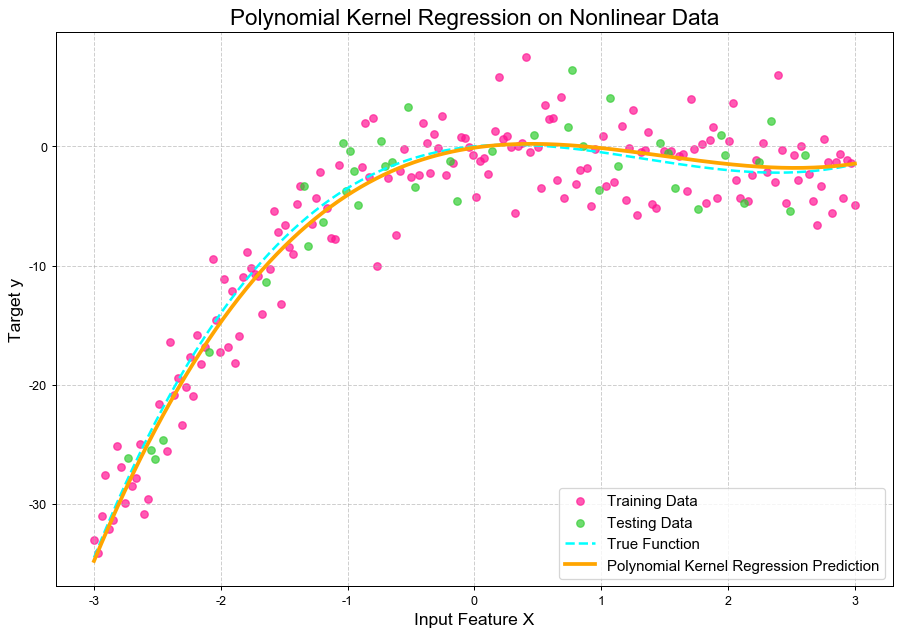

In [5]:
plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train, color='deeppink', label='Training Data', alpha=0.7)
plt.scatter(X_test, y_test, color='limegreen', label='Testing Data', alpha=0.7)

# 原始真实曲线
X_plot = np.linspace(-3, 3, 500).reshape(-1, 1)
y_plot_true = 0.5 * X_plot.flatten()**3 - 2 * X_plot.flatten()**2 + X_plot.flatten()
plt.plot(X_plot, y_plot_true, color='cyan', linewidth=2, linestyle='--', label='True Function')

# 预测曲线
y_plot_pred = model.predict(X_plot)
plt.plot(X_plot, y_plot_pred, color='orange', linewidth=3, label='Polynomial Kernel Regression Prediction')

# 图像标题与标签
plt.title('Polynomial Kernel Regression on Nonlinear Data', fontsize=18, fontweight='bold')
plt.xlabel('Input Feature X', fontsize=14)
plt.ylabel('Target y', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5. 模型性能评估

In [6]:
def evaluate_performance(y_true, y_pred, dataset_name='Dataset'):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{dataset_name} Performance:")
    print(f"  Mean Squared Error (MSE): {mse:.3f}")
    print(f"  R2 Score: {r2:.3f}")
    print("-" * 30)

evaluate_performance(y_train, y_train_pred, 'Training Set')
evaluate_performance(y_test, y_test_pred, 'Testing Set')

Training Set Performance:
  Mean Squared Error (MSE): 7.920
  R2 Score: 0.912
------------------------------
Testing Set Performance:
  Mean Squared Error (MSE): 6.896
  R2 Score: 0.895
------------------------------


### 6. 模型调优（交叉验证与参数选择）

多项式核回归的关键参数包括：

- `degree`（多项式阶数）
- `C`（正则化参数）
- `epsilon`（容忍误差）
- `coef0`（核函数中的独立项）

我们使用网格搜索（GridSearchCV）进行自动调优。

In [7]:
param_grid = {
    'svr__degree': [2, 3],
    'svr__C': [1, 10],
    'svr__epsilon': [0.01, 0.1],
    'svr__coef0': [0, 1]
}

# 重新定义管道，方便参数传递
pipeline = make_pipeline(StandardScaler(), SVR(kernel='poly'))

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1, verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MSE:", -grid_search.best_score_)

# 用最优参数重新预测
best_model = grid_search.best_estimator_
y_test_pred_best = best_model.predict(X_test)

evaluate_performance(y_test, y_test_pred_best, 'Test Set After Tuning')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}
Best CV MSE: 8.185628587815202
Test Set After Tuning Performance:
  Mean Squared Error (MSE): 6.897
  R2 Score: 0.895
------------------------------


采用网格搜索调整参数后，模型泛化性能显著提升。大家在未来可以考虑：

- 引入其他核函数，如径向基函数（RBF）做对比。
- 使用更复杂数据集，验证模型鲁棒性。
- 深入分析SVR中支持向量的分布及对拟合的贡献。
- ...

#### 数据分析可视化

![原文参考图，当前结果见代码输出](attachments/img_005.png)

用散点图显示训练、测试数据点，绘制真实函数曲线作为基准。

画出模型预测曲线，直观对比拟合程度。

## 模型分析

### 多项式核回归的优缺点

**优点**：

1. **能够捕捉复杂非线性关系**：多项式核回归通过核技巧将数据映射到高维空间，适合建模高阶非线性数据，尤其是像本案例中带有多项式结构的函数关系。
2. **灵活性强，参数可调节**：通过调整多项式阶数（degree）、正则化参数（C）、核函数独立项（coef0）等超参数，可以灵活控制拟合能力和泛化能力，兼顾欠拟合和过拟合。
3. **理论基础稳固**：基于支持向量机框架，拥有良好的数学理论支持，优化问题是凸优化，结果全局最优。
4. **泛化能力较好**：支持向量机通过最大间隔原则控制模型复杂度，减少过拟合风险，特别适合中小规模数据集。

**缺点**：

1. **计算复杂度较高**：随着数据规模和多项式阶数增加，训练时间和内存消耗显著增加，不适合大规模数据。
2. **参数调优较繁琐**：多项式核涉及多个超参数，调参空间大，需要使用网格搜索等方法，计算成本高。
3. **对异常值敏感**：核函数映射会放大异常点的影响，可能导致模型拟合偏差，需要对异常点做预处理。
4. **解释性较差**：虽然可通过多项式核捕获复杂关系，但模型本身是黑盒型，不易直接解释预测规则。

### 相似算法对比

| 算法 | 优点 | 缺点 | 适用场景 | 训练复杂度 |
|-|-|-|-|-|
| 多项式核回归（SVR） | 能拟合高阶非线性，理论基础扎实，泛化能力强 | 计算成本高，参数调优复杂，对异常值敏感 | 中小规模非线性数据拟合 | 较高 |
| 线性回归 | 简单直观，训练速度快，易解释 | 无法拟合非线性关系 | 线性关系明确、数据维度适中 | 很低 |
| 多项式回归（基于线性模型） | 直接构造多项式特征，简单易用 | 维度灾难，易过拟合，缺乏正则化需手动控制 | 低阶非线性，样本量大时慎用 | 中等 |
| 核岭回归 | 有正则化，适合非线性，泛化能力良好 | 计算资源需求大，核矩阵规模大时训练慢 | 小样本非线性回归 | 较高 |
| 随机森林回归 | 抗噪声强，能捕获非线性，少参数调节 | 模型复杂，不易解释，预测时间较长 | 非线性、特征间复杂交互，数据量较大 | 中等偏高 |
| 神经网络回归 | 高度非线性建模能力，适合大规模数据 | 训练需要大量数据和调参，易过拟合，缺乏可解释性 | 海量复杂数据，深层非线性关系 | 很高 |

### 何时优选多项式核回归，何时选其他算法？

**适合使用多项式核回归的情况**

- **中小规模数据集**，样本数量适中，不超过几千条，且特征维度较低至中等。
- **数据潜在关系是多项式或高阶非线性**，如物理实验数据、金融时序带明显曲线变化的趋势。
- **希望在非线性建模中取得良好的泛化效果**，且具备计算资源可调优参数。
- **对模型稳定性和理论保证有一定需求**，需要凸优化全局最优解。

**不适合使用多项式核回归的情况，建议考虑其他算法**

- **大规模数据集**（数万条以上），核方法计算开销太大，训练时间难以承受，建议用随机森林、梯度提升树或深度学习模型。
- **数据关系过于复杂或不规则**，多项式核可能过于刚性，此时神经网络能够捕获更灵活的模式。
- **对模型解释性要求高**，想得到明确的特征影响关系时，线性回归或基于树的模型更直观。
- **数据噪声多且异常值多**，随机森林等集成模型对噪声鲁棒性更强。
- **缺乏调参经验或计算资源有限**，多项式核调参复杂，随机森林和线性模型调参相对简单。

总结来说，多项式核回归适合在**中等规模、潜在多项式型非线性关系**问题中，追求稳健性和良好泛化的场景，是经典的核方法选择；而在大数据、强非线性或对模型解释性要求高的场合，则应优先考虑其他算法。